
# <span style="font-family:Georgia; text-align:center;">Actividad: Modelo presa–depredador y métodos numéricos</span> 

<span style="font-family:Georgia;">

**Objetivo.** Explorar el modelo presa–depredador de Lotka–Volterra con parámetros generales e implementar tres métodos numéricos para resolverlo:
1) Euler explícito, 2) Euler implícito (con *predictor–corrector* y *Newton*), y 3) Método del trapecio (también *predictor–corrector* y *Newton*).

**Entregables.**
- Celdas con sus respuestas a las preguntas teóricas (puntos fijos, linealización y comportamiento local).
- Implementaciones de los 3 métodos y gráficas solicitadas.
- Breve discusión de hallazgos (estabilidad, precisión y comportamiento cualitativo).

**Observación:** En el notebook estan las gráficas de las respuestas como una referencia para que puedan ver a donde tienen que llegar. USTEDES tienen que implementar los métodos y hacer sus propias gráficas en el archivo que entreguen.

# <span style="font-family:Georgia; text-align:center;">Modelo y preguntas teóricas</span> 
<span style="font-family:Georgia;">


Consideren el sistema de Lotka–Volterra con parámetros positivos $ \alpha, \beta, \gamma, \delta > 0 $:
$$
\begin{aligned}
\frac{dx}{dt} &= x\,(\alpha - \beta\,y),\\[4pt]
\frac{dy}{dt} &= y\,(-\gamma + \delta\,x).
\end{aligned}
$$

Aquí $x(t)$ representa la población de presas y $y(t)$ la de depredadores. Las constantes tienen la interpretación típica:
- $ \alpha $: tasa de crecimiento de presas en ausencia de depredadores.
- $ \beta $: tasa efectiva de depredación (encuentros presa–depredador).
- $ \gamma $: tasa de muerte de depredadores en ausencia de presas.
- $ \delta $: eficiencia de conversión de presas en nuevos depredadores.

### 1.a) Preguntas de interpretación
- ¿Qué efecto cualitativo esperarían al **aumentar** $ \alpha $? ¿Y al **disminuir** $ \gamma $?
- Si $ \beta $ aumenta, ¿qué cambios esperan en las trayectorias del plano fase?
- ¿Por qué **todas** las constantes deben ser **positivas** en este modelo?

### 1.b) Puntos de equilibrio
1. Encuentren **todos** los puntos de equilibrio resolviendo $ \frac{dx}{dt} = 0 $ y $ \frac{dy}{dt} = 0 $.
2. Escriban su(s) respuesta(s) en la celda siguiente.


### 1.c) Linealización y análisis local
1. Calculen la **matriz Jacobiana**
$$
J(x,y) \;=\;
\begin{pmatrix}
\frac{\partial}{\partial x}\big[x(\alpha-\beta y)\big] & \frac{\partial}{\partial y}\big[x(\alpha-\beta y)\big]\\[4pt]
\frac{\partial}{\partial x}\big[y(-\gamma+\delta x)\big] & \frac{\partial}{\partial y}\big[y(-\gamma+\delta x)\big]
\end{pmatrix}.
$$
2. Evalúen $ J $ en **cada** punto de equilibrio y clasifíquenlos (silla, centro, nodo, foco), justificando con autovalores.
3. Concluyan sobre el **comportamiento local** cerca de los equilibrios.


## **Respuestas**
## 1.a) Interpretación cualitativa

Consideremos el sistema de Lotka–Volterra con parámetros positivos

$$
\dot{x} = x(\alpha - \beta y), 
\qquad
\dot{y} = y(-\gamma + \delta x),
\qquad
\alpha,\beta,\gamma,\delta > 0.
$$

### Si aumenta $\alpha$

El parámetro $\alpha$ representa la tasa de crecimiento intrínseco de las presas en ausencia de depredadores, de modo que si $\alpha$ aumenta, entonces el crecimiento de la población de presas es más rápido cuando $y$ es pequeño.

El equilibrio interior del sistema es

$$
(x^*, y^*) = \left(\frac{\gamma}{\delta}, \frac{\alpha}{\beta}\right).
$$

Al aumentar $\alpha$, la coordenada $y^*$ aumenta, por lo que el equilibrio se desplaza verticalmente hacia arriba en el plano fase.  
En términos biológicos, una mayor capacidad reproductiva de las presas permite sostener una población mayor de depredadores, y las órbitas cerradas del sistema se centran en niveles más altos de $y$.

### Si disminuye $\gamma$

El parámetro $\gamma$ corresponde a la tasa de mortalidad natural de los depredadores en ausencia de presas, por lo que si $\gamma$ disminuye, los depredadores sobreviven más tiempo aun cuando la disponibilidad de presas es baja.

Del equilibrio interior

$$
(x^*, y^*) = \left(\frac{\gamma}{\delta}, \frac{\alpha}{\beta}\right),
$$

se observa que al disminuir $\gamma$, la coordenada $x^*$ disminuye.  
Por tanto, el equilibrio se desplaza hacia la izquierda en el plano fase, y biológicamente esto significa que se requiere una menor población de presas para sostener a los depredadores.

### Si aumenta $\beta$

El parámetro $\beta$ mide la intensidad efectiva de depredación, tal que si $\beta$ aumenta, el término $-\beta xy$ intensifica la disminución de presas en presencia de depredadores.

Esto está dado por:

$$
\alpha - \beta y = 0 
\quad \Longleftrightarrow \quad
y = \frac{\alpha}{\beta}.
$$

Al aumentar $\beta$, esta recta desciende en el plano fase, y el equilibrio interior disminuye en su coordenada $y^*$.  Cualitativamente, la interacción se vuelve más intensa y las oscilaciones se centran en un nuevo equilibrio con menor nivel de depredadores.

### Positividad de los parámetros

Cada constante tiene interpretación biológica como tasa o coeficiente de interacción, por lo que debe ser positiva:

- $\alpha > 0$: las presas crecen en ausencia de depredadores;
- $\beta > 0$: la interacción con depredadores reduce la población de presas;
- $\gamma > 0$: los depredadores mueren en ausencia de presas;
- $\delta > 0$: el consumo de presas contribuye al crecimiento de los depredadores.

Si alguna constante fuera negativa, cambiaría el signo de los términos de crecimiento o interacción, perdiéndose la interpretación ecológica del modelo; además, la positividad garantiza que el primer cuadrante sea invariante y que el equilibrio interior se encuentre en la región biológicamente relevante.

## 1.b) Puntos de equilibrio

Para ello, necesitamos ver que:
$$
x(\alpha - \beta y) = 0,
\qquad
y(-\gamma + \delta x) = 0.
$$

Así, partamos de la primera ecuación:

$$
x(\alpha - \beta y) = 0
$$
$$
\Longrightarrow
x = 0
\quad \text{o} \quad
\alpha - \beta y = 0 \;\Longleftrightarrow\; y = \frac{\alpha}{\beta}.
$$

Luego, tomemos a la segunda ecuacion y evamos que:

$$
y(-\gamma + \delta x) = 0
$$

$$
\Longrightarrow
y = 0
\quad \text{o} \quad
-\gamma + \delta x = 0 \;\Longleftrightarrow\; x = \frac{\gamma}{\delta}.
$$

Ahora bien, puntos que satisfacen ambas ecuaciones son:

1. Si $x = 0$ y $y = 0$, obtenemos el equilibrio trivial:
   $$
   (0,0).
   $$

2. Si $y = \dfrac{\alpha}{\beta}$ y $x = \dfrac{\gamma}{\delta}$, obtenemos el equilibrio interior:
   $$
   \left(\frac{\gamma}{\delta}, \frac{\alpha}{\beta}\right).
   $$

Con todo lo anterior, podemos afirmar que el sistema tiene exactamente dos puntos de equilibrio:

$$
(0,0)
\quad \text{y} \quad
\left(\frac{\gamma}{\delta}, \frac{\alpha}{\beta}\right).
$$

## 1.c) Linealización y análisis local

Consideremos el sistema

$$
\dot{x} = x(\alpha - \beta y), 
\qquad
\dot{y} = y(-\gamma + \delta x),
\qquad
\alpha,\beta,\gamma,\delta > 0.
$$

Primero, calculemos las derivadas parciales:

$$
\frac{\partial}{\partial x}[x(\alpha-\beta y)] = \alpha - \beta y,
\qquad
\frac{\partial}{\partial y}[x(\alpha-\beta y)] = -\beta x,
$$

$$
\frac{\partial}{\partial x}[y(-\gamma+\delta x)] = \delta y,
\qquad
\frac{\partial}{\partial y}[y(-\gamma+\delta x)] = -\gamma + \delta x.
$$

Por tanto, la matriz Jacobiana es

$$
J(x,y) =
\begin{pmatrix}
\alpha - \beta y & -\beta x \\
\delta y & -\gamma + \delta x
\end{pmatrix}.
$$

Luego, saebmos que los puntos de equilibrio son:

$$
(0,0),
\qquad
\left(\frac{\gamma}{\delta}, \frac{\alpha}{\beta}\right).
$$

Por lo que:
#### (i) En $(0,0)$

$$
J(0,0) =
\begin{pmatrix}
\alpha & 0 \\
0 & -\gamma
\end{pmatrix}.
$$

Los autovalores son

$$
\lambda_1 = \alpha > 0,
\qquad
\lambda_2 = -\gamma < 0.
$$

Como tienen signos opuestos, el origen es un **punto silla**.


#### (ii) En $\left(\frac{\gamma}{\delta}, \frac{\alpha}{\beta}\right)$

Sustituyendo en la matriz:

$$
J\left(\frac{\gamma}{\delta}, \frac{\alpha}{\beta}\right)
=
\begin{pmatrix}
0 & -\beta \frac{\gamma}{\delta} \\
\delta \frac{\alpha}{\beta} & 0
\end{pmatrix}.
$$

Esto es,

$$
J^* =
\begin{pmatrix}
0 & -\frac{\beta\gamma}{\delta} \\
\frac{\delta\alpha}{\beta} & 0
\end{pmatrix}.
$$

El polinomio característico es

$$
\lambda^2 + \alpha\gamma = 0,
$$

por lo que

$$
\lambda = \pm i\sqrt{\alpha\gamma}.
$$

Los autovalores son puramente imaginarios y conjugados complejos.

Por tanto, el equilibrio interior es un **centro** (linealmente).

Con todo esto, tendremos que el origen $(0,0)$ es un punto silla, por lo que es inestable. Luego, el equilibrio interior 
  $
  \left(\frac{\gamma}{\delta}, \frac{\alpha}{\beta}\right)
  $
  es un centro lineal. 

En el modelo clásico de Lotka–Volterra, este centro no es asintóticamente estable, pues trayectorias forman órbitas cerradas alrededor del equilibrio, lo que implica oscilaciones periódicas en las poblaciones de presas y depredadores.

## <span style="font-family:Georgia; text-align:center;">Invariante</span> 
<span style="font-family:Georgia;">

Para el sistema de Lotka–Volterra, la función
$$
H(x,y) \;=\; \delta\,x - \gamma\,\ln x \;+\; \beta\,y - \alpha\,\ln y
$$
es constante a lo largo de trayectorias **exactas** (cuando $x>0$, $y>0$).

Pueden evaluar $H$ a lo largo de soluciones numéricas para observar **deriva** (pérdida/ganancia) de esta cantidad y comparar métodos.


## <span style="font-family:Georgia; text-align:center;">Métodos numéricos a implementar</span> 
<span style="font-family:Georgia;">

Usen los siguientes parámetros por defecto:
$$
\alpha = 1.0,\quad \beta = 0.5,\quad \gamma = 1.0,\quad \delta = 0.5.
$$
Condición inicial positiva:
$$
x(0) = 2.0,\quad y(0) = 1.5.
$$
Intervalo temporal y paso:
$$
[t_0, t_f] = [0, 40],\quad h = 0.05.
$$

### 3.a) Implementación y corrida básica
1. Simulen con **Euler explícito** y grafiquen $x(t)$, $y(t)$ y el plano fase.  
2. Repitan con **Euler implícito (Predictor-Corrector y Newton)** y con **trapecio (PC y Newton)**.  
3. (Extra) Grafiquen $H(x,y)$ para comparar deriva entre métodos.

### 3.b) Comparación de estabilidad y precisión
- Repitan con distintos $h$ (ej. $h=0.2$, $h=0.1$, $h=0.05$, $h=0.01$).  
- ¿Cuál método conserva mejor la cualidad de órbitas cerradas en el plano fase?

### 3.c) Experimentos con parámetros
- Cambien $ \alpha, \beta, \gamma, \delta $ y observen cómo se modifica el plano fase.  
- ¿Qué sucede si la condición inicial se acerca a los ejes (casi cero)? Comenten sobre restricciones $x>0$, $y>0$ para que $H$ sea válido.



# **Respuestas**
### **3.a)**

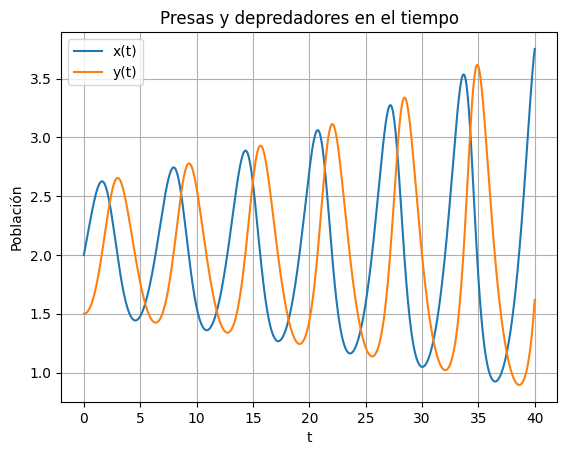

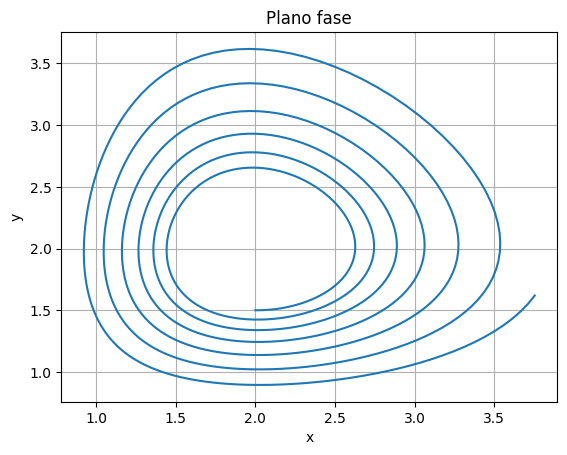

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def euler_modificado(f, g, a, b, x0, y0, n):
    delta_t = (b - a) / n
    T = np.array([])
    Y = np.array([])
    X = np.array([])
    T = np.append(T, a)
    X = np.append(X, x0)
    Y = np.append(Y, y0)
    for i in range(1, n + 1):
        T = np.append(T, a + i * delta_t)
        Fx = f(T[i-1], X[i-1], Y[i-1])
        Gy = g(T[i-1], X[i-1], Y[i-1])
        X = np.append(X, X[i-1] + Fx * delta_t)
        Y = np.append(Y, Y[i-1] + Gy * delta_t)
    return X, Y

alpha = 1.0
beta = 0.5
gamma = 1.0
delta = 0.5
a = 0
b = 40
h = 0.05
n = int((b - a) / h)
x0 = 2.0
y0 = 1.5

def f(t, x, y):
    return x * (alpha - beta * y)

def g(t, x, y):
    return y * (-gamma + delta * x)

X, Y = euler_modificado(f, g, a, b, x0, y0, n)
T = np.linspace(a, b, n + 1)

plt.figure()
plt.plot(T, X, label='x(t)')
plt.plot(T, Y, label='y(t)')
plt.xlabel('t')
plt.ylabel('Población')
plt.title('Presas y depredadores en el tiempo')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(X, Y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Plano fase')
plt.grid(True)
plt.show()


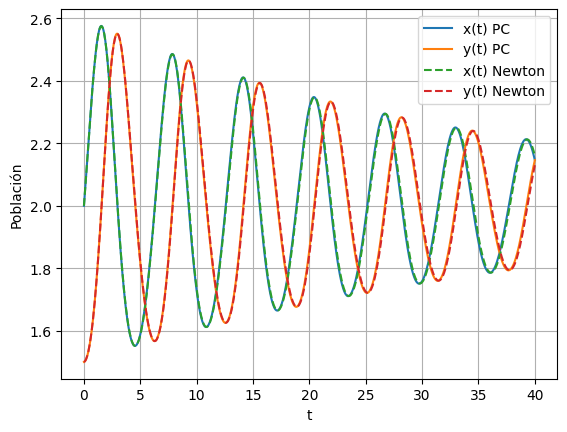

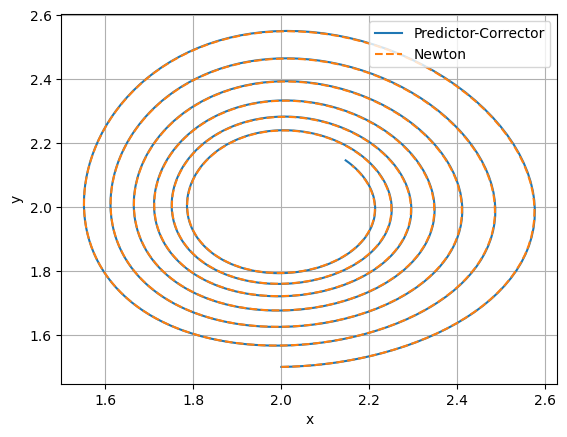

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Euler implícito - PC
def euler_imp_pc(a, b, x0, y0, n):
    delta_t = (b - a) / n
    X = np.zeros(n + 1)
    Y = np.zeros(n + 1)
    X[0] = x0
    Y[0] = y0
    for i in range(n):
        x_pred = X[i] + delta_t * f(X[i], Y[i])
        y_pred = Y[i] + delta_t * g(X[i], Y[i])
        X[i+1] = X[i] + delta_t * f(x_pred, y_pred)
        Y[i+1] = Y[i] + delta_t * g(x_pred, y_pred)
    return X, Y


# Euler implícito - Newton
def euler_imp_newton(a, b, x0, y0, n):
    delta_t = (b - a) / n
    X = np.zeros(n + 1)
    Y = np.zeros(n + 1)
    X[0] = x0
    Y[0] = y0
    for i in range(n):
        xk = X[i]
        yk = Y[i]
        x_next = xk + delta_t * f(xk, yk)
        y_next = yk + delta_t * g(xk, yk)
        for _ in range(5):
            F1 = x_next - xk - delta_t * f(x_next, y_next)
            F2 = y_next - yk - delta_t * g(x_next, y_next)
            J11 = 1 - delta_t * (alpha - beta * y_next)
            J12 = delta_t * beta * x_next
            J21 = -delta_t * delta * y_next
            J22 = 1 - delta_t * (-gamma + delta * x_next)
            det = J11 * J22 - J12 * J21
            dx = (-F1 * J22 + F2 * J12) / det
            dy = (-J11 * F2 + J21 * F1) / det
            x_next += dx
            y_next += dy
        X[i+1] = x_next
        Y[i+1] = y_next
    return X, Y


alpha = 1.0
beta = 0.5
gamma = 1.0
delta = 0.5

def f(x, y):
    return x * (alpha - beta * y)

def g(x, y):
    return y * (-gamma + delta * x)

a = 0
b = 40
h = 0.05
n = int((b - a) / h)
x0 = 2.0
y0 = 1.5
T = np.linspace(a, b, n + 1)

X_pc, Y_pc = euler_imp_pc(a, b, x0, y0, n)
X_new, Y_new = euler_imp_newton(a, b, x0, y0, n)

plt.figure()
plt.plot(T, X_pc, label='x(t) PC')
plt.plot(T, Y_pc, label='y(t) PC')
plt.plot(T, X_new, '--', label='x(t) Newton')
plt.plot(T, Y_new, '--', label='y(t) Newton')
plt.xlabel('t')
plt.ylabel('Población')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(X_pc, Y_pc, label='Predictor-Corrector')
plt.plot(X_new, Y_new, '--', label='Newton')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

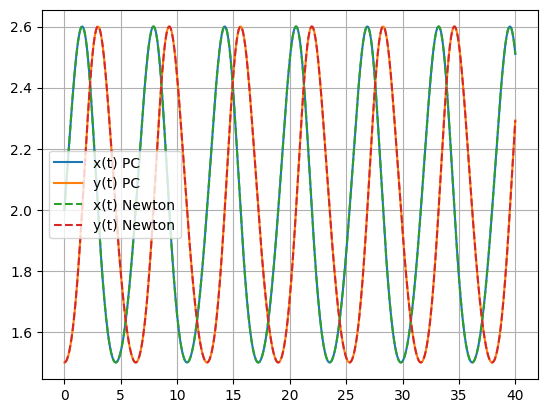

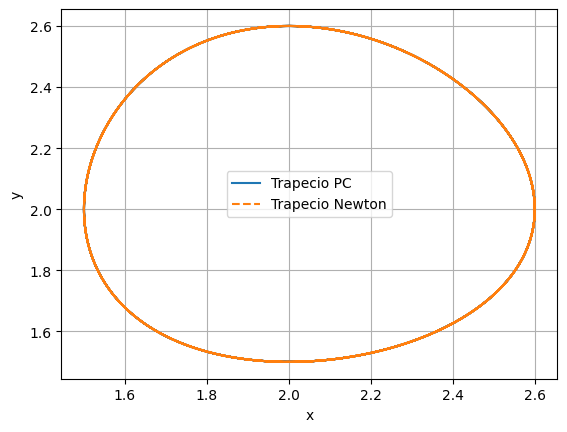

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def trapecio_pc(params, F, z0, t0, tf, h, tol, max_iter):
    N = int((tf - t0) / h)
    T = np.zeros(N + 1)
    Z = np.zeros((N + 1, len(z0)))
    T[0] = t0
    Z[0] = z0
    for i in range(N):
        F_n = F(params, T[i], Z[i])
        Z_pred = Z[i] + h * F_n
        for k in range(max_iter):
            Z_new = Z[i] + (h/2) * (F_n + F(params, T[i] + h, Z_pred))
            if np.linalg.norm(Z_new - Z_pred) < tol:
                break
            Z_pred = Z_new
        Z[i+1] = Z_new
        T[i+1] = T[i] + h
    return T, Z

def trapecio_newton(params, F, z0, t0, tf, h, tol, max_iter):
    N = int((tf - t0) / h)
    T = np.zeros(N + 1)
    Z = np.zeros((N + 1, len(z0)))
    T[0] = t0
    Z[0] = z0
    for i in range(N):
        z_n = Z[i]
        F_n = F(params, T[i], z_n)
        z_next = z_n + h * F_n
        for k in range(max_iter):
            F_next = F(params, T[i] + h, z_next)
            G = z_next - z_n - (h/2) * (F_n + F_next)
            x, y = z_next
            alpha = params["alpha"]
            beta = params["beta"]
            delta = params["delta"]
            gamma = params["gamma"]
            JF = np.array([
                [alpha - beta*y, -beta*x],
                [delta*y, delta*x - gamma]
            ])
            J = np.eye(2) - (h/2) * JF
            dz = np.linalg.solve(J, -G)
            z_next = z_next + dz
            if np.linalg.norm(dz) < tol:
                break
        Z[i+1] = z_next
        T[i+1] = T[i] + h
    return T, Z

def F(params, t, z):
    alpha = params["alpha"]
    beta = params["beta"]
    delta = params["delta"]
    gamma = params["gamma"]
    x, y = z
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return np.array([dxdt, dydt])

params = {
    "alpha": 1.0,
    "beta": 0.5,
    "delta": 0.5,
    "gamma": 1.0,
    "x0": 2.0,
    "y0": 1.5}

t0 = 0
tf = 40
h = 0.05
tol = 1e-10
max_iter = 30

z0 = np.array([params["x0"], params["y0"]])

T_pc, Z_pc = trapecio_pc(params, F, z0, t0, tf, h, tol, max_iter)
T_new, Z_new = trapecio_newton(params, F, z0, t0, tf, h, tol, max_iter)

plt.figure()
plt.plot(T_pc, Z_pc[:, 0], label='x(t) PC')
plt.plot(T_pc, Z_pc[:, 1], label='y(t) PC')
plt.plot(T_new, Z_new[:, 0], '--', label='x(t) Newton')
plt.plot(T_new, Z_new[:, 1], '--', label='y(t) Newton')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(Z_pc[:, 0], Z_pc[:, 1], label='Trapecio PC')
plt.plot(Z_new[:, 0], Z_new[:, 1], '--', label='Trapecio Newton')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

### **3.b)**

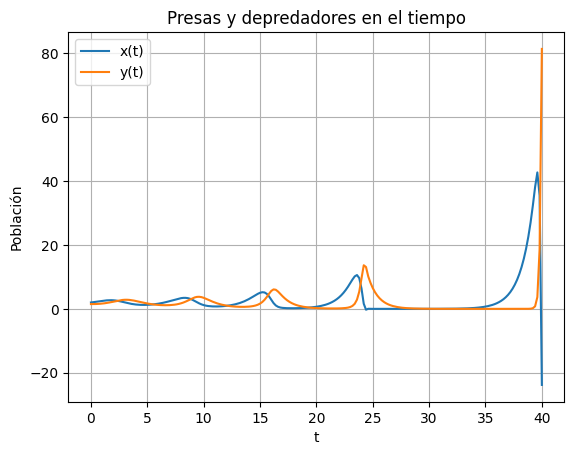

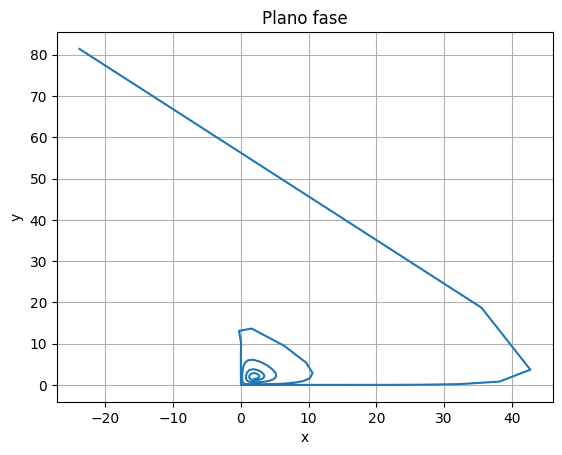

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def euler_modificado(f, g, a, b, x0, y0, n):
    delta_t = (b - a) / n
    T = np.array([])
    Y = np.array([])
    X = np.array([])
    T = np.append(T, a)
    X = np.append(X, x0)
    Y = np.append(Y, y0)
    for i in range(1, n + 1):
        T = np.append(T, a + i * delta_t)
        Fx = f(T[i-1], X[i-1], Y[i-1])
        Gy = g(T[i-1], X[i-1], Y[i-1])
        X = np.append(X, X[i-1] + Fx * delta_t)
        Y = np.append(Y, Y[i-1] + Gy * delta_t)
    return X, Y

alpha = 1.0
beta = 0.5
gamma = 1.0
delta = 0.5
a = 0
b = 40
h = 0.2
n = int((b - a) / h)
x0 = 2.0
y0 = 1.5

def f(t, x, y):
    return x * (alpha - beta * y)

def g(t, x, y):
    return y * (-gamma + delta * x)

X, Y = euler_modificado(f, g, a, b, x0, y0, n)
T = np.linspace(a, b, n + 1)

plt.figure()
plt.plot(T, X, label='x(t)')
plt.plot(T, Y, label='y(t)')
plt.xlabel('t')
plt.ylabel('Población')
plt.title('Presas y depredadores en el tiempo')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(X, Y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Plano fase')
plt.grid(True)
plt.show()


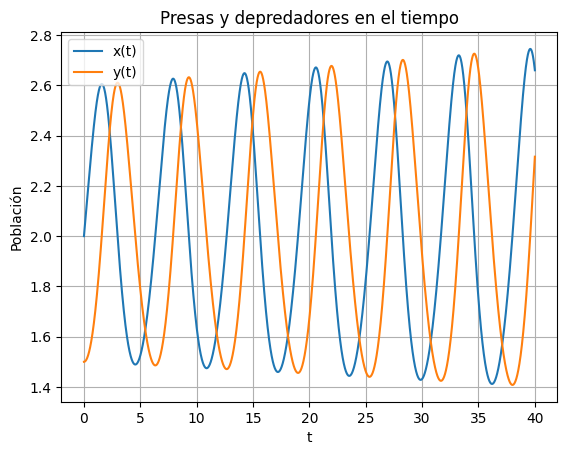

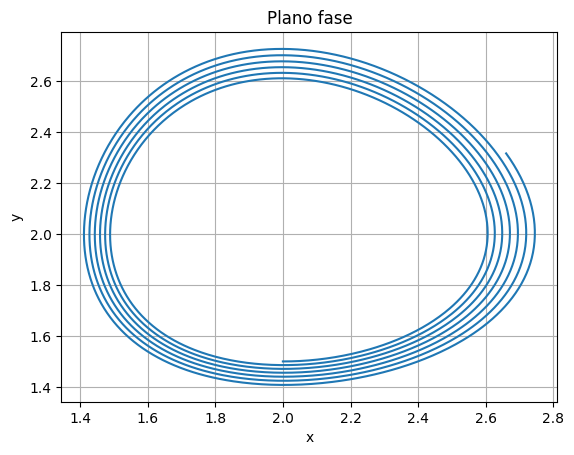

In [32]:
h = 0.01
n = int((b - a) / h)

X, Y = euler_modificado(f, g, a, b, x0, y0, n)
T = np.linspace(a, b, n + 1)

plt.figure()
plt.plot(T, X, label='x(t)')
plt.plot(T, Y, label='y(t)')
plt.xlabel('t')
plt.ylabel('Población')
plt.title('Presas y depredadores en el tiempo')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(X, Y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Plano fase')
plt.grid(True)
plt.show()


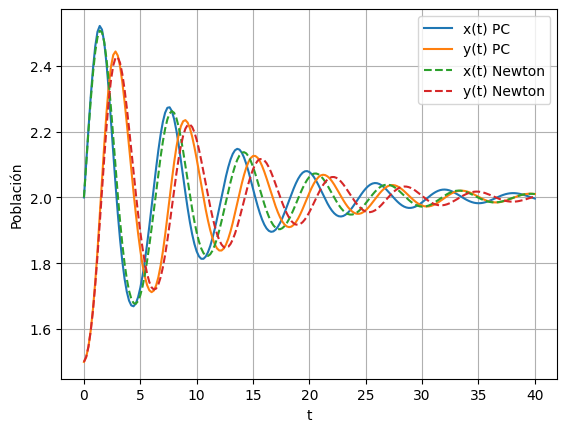

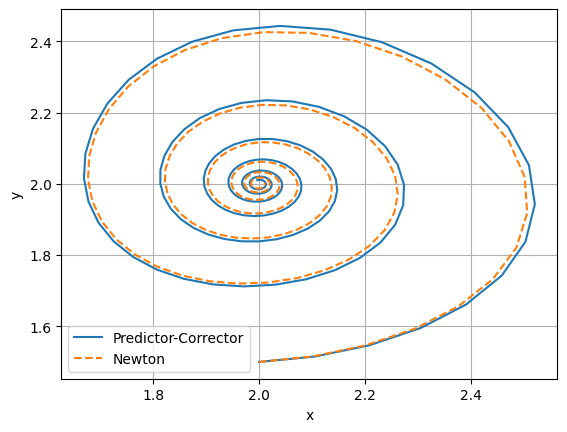

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Euler implícito - PC
def euler_imp_pc(a, b, x0, y0, n):
    delta_t = (b - a) / n
    X = np.zeros(n + 1)
    Y = np.zeros(n + 1)
    X[0] = x0
    Y[0] = y0
    for i in range(n):
        x_pred = X[i] + delta_t * f(X[i], Y[i])
        y_pred = Y[i] + delta_t * g(X[i], Y[i])
        X[i+1] = X[i] + delta_t * f(x_pred, y_pred)
        Y[i+1] = Y[i] + delta_t * g(x_pred, y_pred)
    return X, Y


# Euler implícito - Newton
def euler_imp_newton(a, b, x0, y0, n):
    delta_t = (b - a) / n
    X = np.zeros(n + 1)
    Y = np.zeros(n + 1)
    X[0] = x0
    Y[0] = y0
    for i in range(n):
        xk = X[i]
        yk = Y[i]
        x_next = xk + delta_t * f(xk, yk)
        y_next = yk + delta_t * g(xk, yk)
        for _ in range(5):
            F1 = x_next - xk - delta_t * f(x_next, y_next)
            F2 = y_next - yk - delta_t * g(x_next, y_next)
            J11 = 1 - delta_t * (alpha - beta * y_next)
            J12 = delta_t * beta * x_next
            J21 = -delta_t * delta * y_next
            J22 = 1 - delta_t * (-gamma + delta * x_next)
            det = J11 * J22 - J12 * J21
            dx = (-F1 * J22 + F2 * J12) / det
            dy = (-J11 * F2 + J21 * F1) / det
            x_next += dx
            y_next += dy
        X[i+1] = x_next
        Y[i+1] = y_next
    return X, Y


alpha = 1.0
beta = 0.5
gamma = 1.0
delta = 0.5

def f(x, y):
    return x * (alpha - beta * y)

def g(x, y):
    return y * (-gamma + delta * x)

a = 0
b = 40
h = 0.2
n = int((b - a) / h)
x0 = 2.0
y0 = 1.5
T = np.linspace(a, b, n + 1)

X_pc, Y_pc = euler_imp_pc(a, b, x0, y0, n)
X_new, Y_new = euler_imp_newton(a, b, x0, y0, n)

plt.figure()
plt.plot(T, X_pc, label='x(t) PC')
plt.plot(T, Y_pc, label='y(t) PC')
plt.plot(T, X_new, '--', label='x(t) Newton')
plt.plot(T, Y_new, '--', label='y(t) Newton')
plt.xlabel('t')
plt.ylabel('Población')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(X_pc, Y_pc, label='Predictor-Corrector')
plt.plot(X_new, Y_new, '--', label='Newton')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

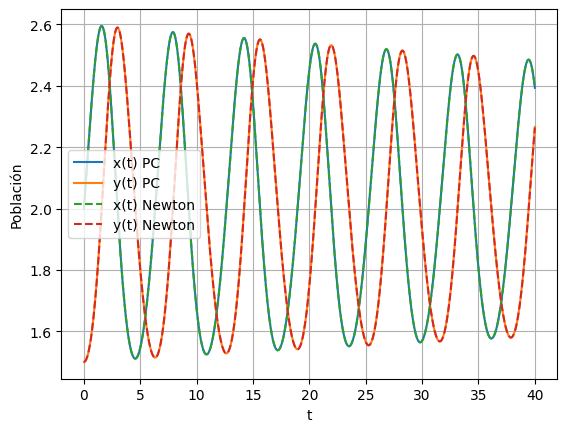

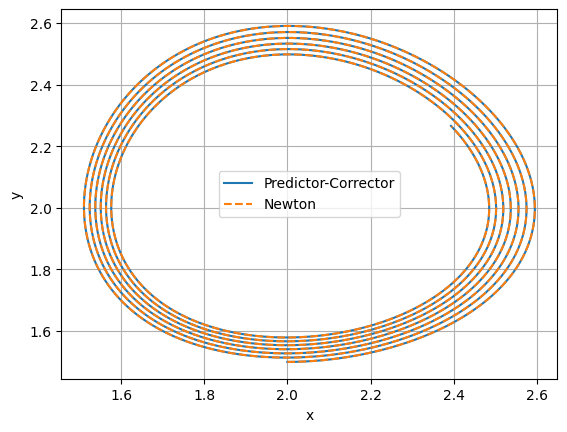

In [34]:
h = 0.01
n = int((b - a) / h)

T = np.linspace(a, b, n + 1)

X_pc, Y_pc = euler_imp_pc(a, b, x0, y0, n)
X_new, Y_new = euler_imp_newton(a, b, x0, y0, n)

plt.figure()
plt.plot(T, X_pc, label='x(t) PC')
plt.plot(T, Y_pc, label='y(t) PC')
plt.plot(T, X_new, '--', label='x(t) Newton')
plt.plot(T, Y_new, '--', label='y(t) Newton')
plt.xlabel('t')
plt.ylabel('Población')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(X_pc, Y_pc, label='Predictor-Corrector')
plt.plot(X_new, Y_new, '--', label='Newton')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

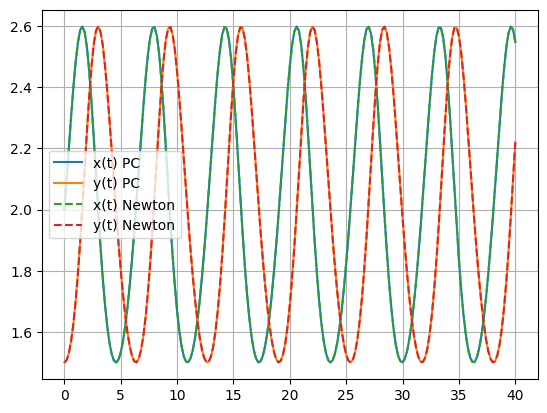

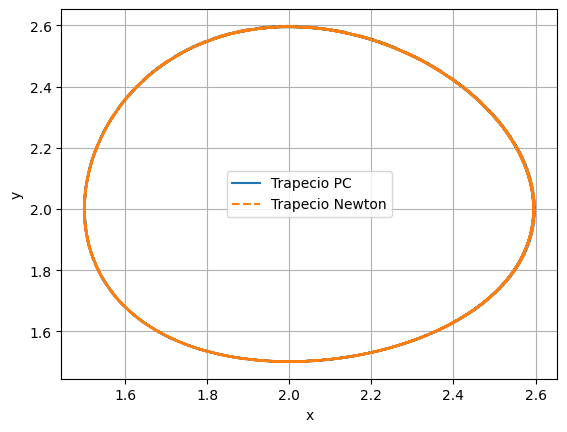

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def trapecio_pc(params, F, z0, t0, tf, h, tol, max_iter):
    N = int((tf - t0) / h)
    T = np.zeros(N + 1)
    Z = np.zeros((N + 1, len(z0)))
    T[0] = t0
    Z[0] = z0
    for i in range(N):
        F_n = F(params, T[i], Z[i])
        Z_pred = Z[i] + h * F_n
        for k in range(max_iter):
            Z_new = Z[i] + (h/2) * (F_n + F(params, T[i] + h, Z_pred))
            if np.linalg.norm(Z_new - Z_pred) < tol:
                break
            Z_pred = Z_new
        Z[i+1] = Z_new
        T[i+1] = T[i] + h
    return T, Z

def trapecio_newton(params, F, z0, t0, tf, h, tol, max_iter):
    N = int((tf - t0) / h)
    T = np.zeros(N + 1)
    Z = np.zeros((N + 1, len(z0)))
    T[0] = t0
    Z[0] = z0
    for i in range(N):
        z_n = Z[i]
        F_n = F(params, T[i], z_n)
        z_next = z_n + h * F_n
        for k in range(max_iter):
            F_next = F(params, T[i] + h, z_next)
            G = z_next - z_n - (h/2) * (F_n + F_next)
            x, y = z_next
            alpha = params["alpha"]
            beta = params["beta"]
            delta = params["delta"]
            gamma = params["gamma"]
            JF = np.array([
                [alpha - beta*y, -beta*x],
                [delta*y, delta*x - gamma]
            ])
            J = np.eye(2) - (h/2) * JF
            dz = np.linalg.solve(J, -G)
            z_next = z_next + dz
            if np.linalg.norm(dz) < tol:
                break
        Z[i+1] = z_next
        T[i+1] = T[i] + h
    return T, Z

def F(params, t, z):
    alpha = params["alpha"]
    beta = params["beta"]
    delta = params["delta"]
    gamma = params["gamma"]
    x, y = z
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return np.array([dxdt, dydt])

params = {
    "alpha": 1.0,
    "beta": 0.5,
    "delta": 0.5,
    "gamma": 1.0,
    "x0": 2.0,
    "y0": 1.5}

t0 = 0
tf = 40
h = 0.2
tol = 1e-10
max_iter = 30

z0 = np.array([params["x0"], params["y0"]])

T_pc, Z_pc = trapecio_pc(params, F, z0, t0, tf, h, tol, max_iter)
T_new, Z_new = trapecio_newton(params, F, z0, t0, tf, h, tol, max_iter)

plt.figure()
plt.plot(T_pc, Z_pc[:, 0], label='x(t) PC')
plt.plot(T_pc, Z_pc[:, 1], label='y(t) PC')
plt.plot(T_new, Z_new[:, 0], '--', label='x(t) Newton')
plt.plot(T_new, Z_new[:, 1], '--', label='y(t) Newton')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(Z_pc[:, 0], Z_pc[:, 1], label='Trapecio PC')
plt.plot(Z_new[:, 0], Z_new[:, 1], '--', label='Trapecio Newton')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

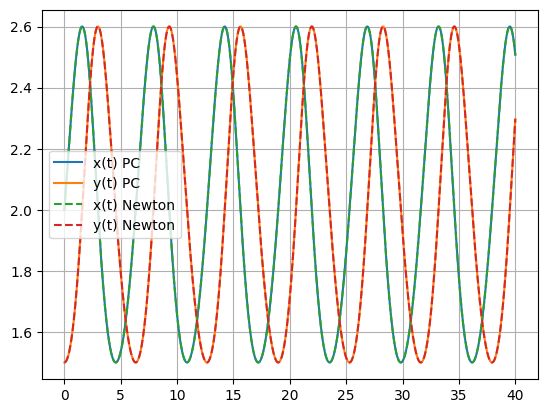

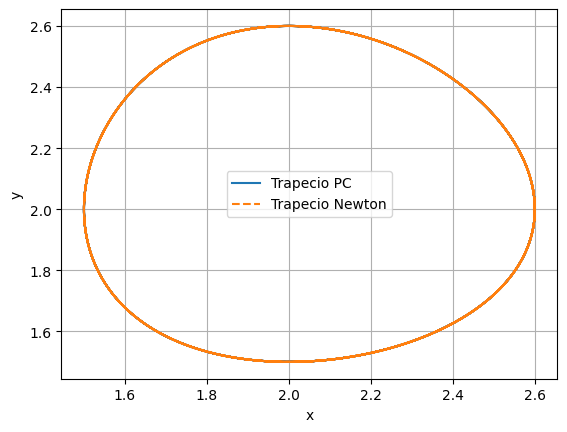

In [36]:
h = 0.01

T_pc, Z_pc = trapecio_pc(params, F, z0, t0, tf, h, tol, max_iter)
T_new, Z_new = trapecio_newton(params, F, z0, t0, tf, h, tol, max_iter)

plt.figure()
plt.plot(T_pc, Z_pc[:, 0], label='x(t) PC')
plt.plot(T_pc, Z_pc[:, 1], label='y(t) PC')
plt.plot(T_new, Z_new[:, 0], '--', label='x(t) Newton')
plt.plot(T_new, Z_new[:, 1], '--', label='y(t) Newton')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(Z_pc[:, 0], Z_pc[:, 1], label='Trapecio PC')
plt.plot(Z_new[:, 0], Z_new[:, 1], '--', label='Trapecio Newton')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Como pudimos observar, el método del Trapecio es claramente mejor a la hora de conservar la cualidad de órbitas cerradas en el plano fase, ya que con distintas h ni siquiera hubo cambios, en comparación con el resto, donde hubo deformaciones muy evidentes.

### **3.c)**

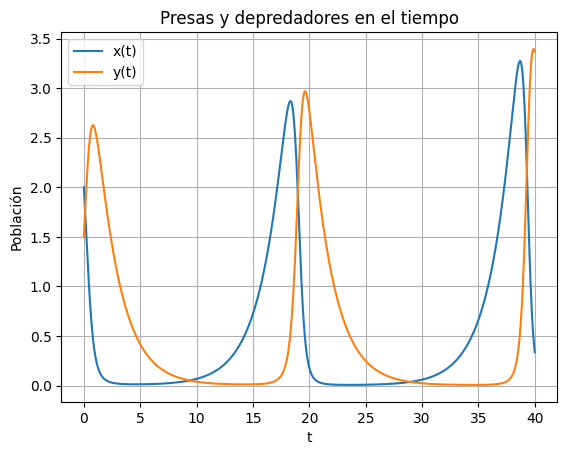

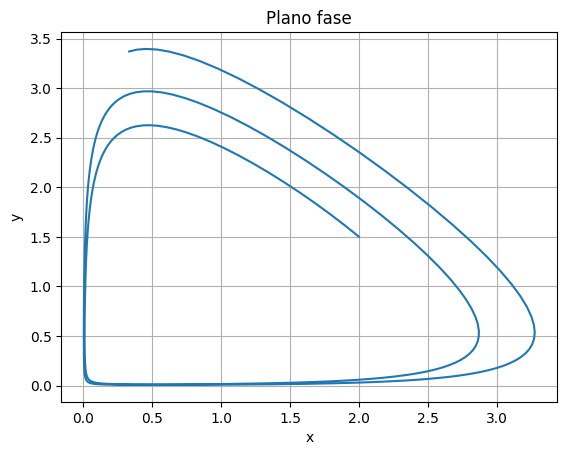

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def euler_modificado(f, g, a, b, x0, y0, n):
    delta_t = (b - a) / n
    T = np.array([])
    Y = np.array([])
    X = np.array([])
    T = np.append(T, a)
    X = np.append(X, x0)
    Y = np.append(Y, y0)
    for i in range(1, n + 1):
        T = np.append(T, a + i * delta_t)
        Fx = f(T[i-1], X[i-1], Y[i-1])
        Gy = g(T[i-1], X[i-1], Y[i-1])
        X = np.append(X, X[i-1] + Fx * delta_t)
        Y = np.append(Y, Y[i-1] + Gy * delta_t)
    return X, Y

alpha = 0.5
beta = 1
gamma = 0.5
delta = 1
a = 0
b = 40
h = 0.05
n = int((b - a) / h)
x0 = 2.0
y0 = 1.5

def f(t, x, y):
    return x * (alpha - beta * y)

def g(t, x, y):
    return y * (-gamma + delta * x)

X, Y = euler_modificado(f, g, a, b, x0, y0, n)
T = np.linspace(a, b, n + 1)

plt.figure()
plt.plot(T, X, label='x(t)')
plt.plot(T, Y, label='y(t)')
plt.xlabel('t')
plt.ylabel('Población')
plt.title('Presas y depredadores en el tiempo')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(X, Y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Plano fase')
plt.grid(True)
plt.show()


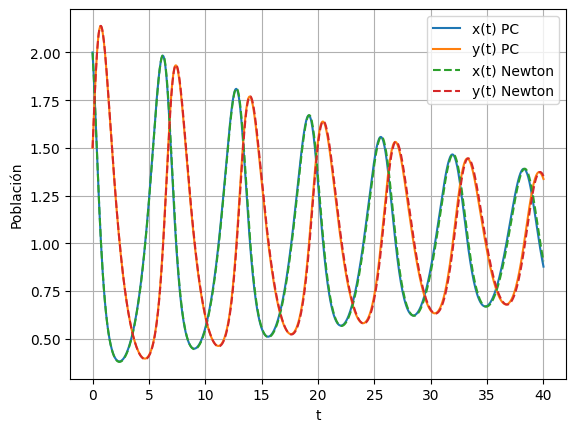

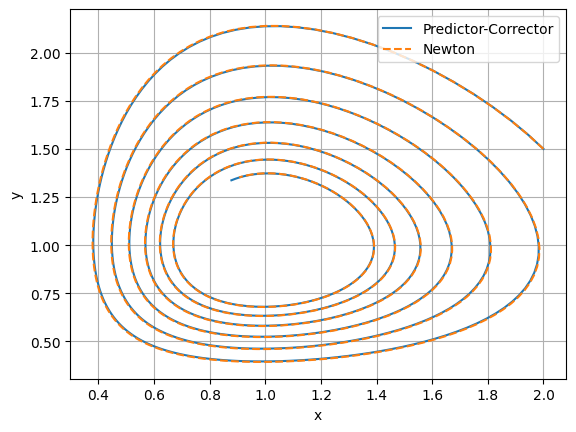

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Euler implícito - PC
def euler_imp_pc(a, b, x0, y0, n):
    delta_t = (b - a) / n
    X = np.zeros(n + 1)
    Y = np.zeros(n + 1)
    X[0] = x0
    Y[0] = y0
    for i in range(n):
        x_pred = X[i] + delta_t * f(X[i], Y[i])
        y_pred = Y[i] + delta_t * g(X[i], Y[i])
        X[i+1] = X[i] + delta_t * f(x_pred, y_pred)
        Y[i+1] = Y[i] + delta_t * g(x_pred, y_pred)
    return X, Y


# Euler implícito - Newton
def euler_imp_newton(a, b, x0, y0, n):
    delta_t = (b - a) / n
    X = np.zeros(n + 1)
    Y = np.zeros(n + 1)
    X[0] = x0
    Y[0] = y0
    for i in range(n):
        xk = X[i]
        yk = Y[i]
        x_next = xk + delta_t * f(xk, yk)
        y_next = yk + delta_t * g(xk, yk)
        for _ in range(5):
            F1 = x_next - xk - delta_t * f(x_next, y_next)
            F2 = y_next - yk - delta_t * g(x_next, y_next)
            J11 = 1 - delta_t * (alpha - beta * y_next)
            J12 = delta_t * beta * x_next
            J21 = -delta_t * delta * y_next
            J22 = 1 - delta_t * (-gamma + delta * x_next)
            det = J11 * J22 - J12 * J21
            dx = (-F1 * J22 + F2 * J12) / det
            dy = (-J11 * F2 + J21 * F1) / det
            x_next += dx
            y_next += dy
        X[i+1] = x_next
        Y[i+1] = y_next
    return X, Y


alpha = 1
beta = 1
gamma = 1
delta = 1

def f(x, y):
    return x * (alpha - beta * y)

def g(x, y):
    return y * (-gamma + delta * x)

a = 0
b = 40
h = 0.05
n = int((b - a) / h)
x0 = 2.0
y0 = 1.5
T = np.linspace(a, b, n + 1)

X_pc, Y_pc = euler_imp_pc(a, b, x0, y0, n)
X_new, Y_new = euler_imp_newton(a, b, x0, y0, n)

plt.figure()
plt.plot(T, X_pc, label='x(t) PC')
plt.plot(T, Y_pc, label='y(t) PC')
plt.plot(T, X_new, '--', label='x(t) Newton')
plt.plot(T, Y_new, '--', label='y(t) Newton')
plt.xlabel('t')
plt.ylabel('Población')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(X_pc, Y_pc, label='Predictor-Corrector')
plt.plot(X_new, Y_new, '--', label='Newton')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

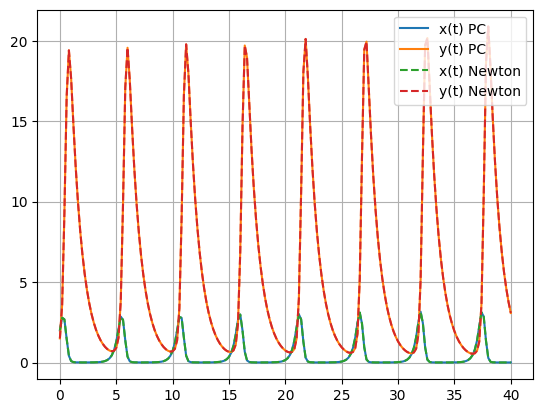

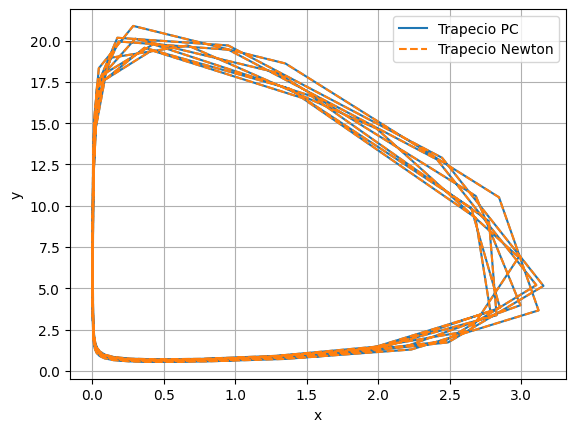

In [39]:
import numpy as np
import matplotlib.pyplot as plt

def trapecio_pc(params, F, z0, t0, tf, h, tol, max_iter):
    N = int((tf - t0) / h)
    T = np.zeros(N + 1)
    Z = np.zeros((N + 1, len(z0)))
    T[0] = t0
    Z[0] = z0
    for i in range(N):
        F_n = F(params, T[i], Z[i])
        Z_pred = Z[i] + h * F_n
        for k in range(max_iter):
            Z_new = Z[i] + (h/2) * (F_n + F(params, T[i] + h, Z_pred))
            if np.linalg.norm(Z_new - Z_pred) < tol:
                break
            Z_pred = Z_new
        Z[i+1] = Z_new
        T[i+1] = T[i] + h
    return T, Z

def trapecio_newton(params, F, z0, t0, tf, h, tol, max_iter):
    N = int((tf - t0) / h)
    T = np.zeros(N + 1)
    Z = np.zeros((N + 1, len(z0)))
    T[0] = t0
    Z[0] = z0
    for i in range(N):
        z_n = Z[i]
        F_n = F(params, T[i], z_n)
        z_next = z_n + h * F_n
        for k in range(max_iter):
            F_next = F(params, T[i] + h, z_next)
            G = z_next - z_n - (h/2) * (F_n + F_next)
            x, y = z_next
            alpha = params["alpha"]
            beta = params["beta"]
            delta = params["delta"]
            gamma = params["gamma"]
            JF = np.array([
                [alpha - beta*y, -beta*x],
                [delta*y, delta*x - gamma]
            ])
            J = np.eye(2) - (h/2) * JF
            dz = np.linalg.solve(J, -G)
            z_next = z_next + dz
            if np.linalg.norm(dz) < tol:
                break
        Z[i+1] = z_next
        T[i+1] = T[i] + h
    return T, Z

def F(params, t, z):
    alpha = params["alpha"]
    beta = params["beta"]
    delta = params["delta"]
    gamma = params["gamma"]
    x, y = z
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return np.array([dxdt, dydt])

params = {
    "alpha": 3,
    "beta": 0.5,
    "delta": 2,
    "gamma": 1.0,
    "x0": 2.0,
    "y0": 1.5}

t0 = 0
tf = 40
h = 0.2
tol = 1e-10
max_iter = 30

z0 = np.array([params["x0"], params["y0"]])

T_pc, Z_pc = trapecio_pc(params, F, z0, t0, tf, h, tol, max_iter)
T_new, Z_new = trapecio_newton(params, F, z0, t0, tf, h, tol, max_iter)

plt.figure()
plt.plot(T_pc, Z_pc[:, 0], label='x(t) PC')
plt.plot(T_pc, Z_pc[:, 1], label='y(t) PC')
plt.plot(T_new, Z_new[:, 0], '--', label='x(t) Newton')
plt.plot(T_new, Z_new[:, 1], '--', label='y(t) Newton')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(Z_pc[:, 0], Z_pc[:, 1], label='Trapecio PC')
plt.plot(Z_new[:, 0], Z_new[:, 1], '--', label='Trapecio Newton')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Si la condición inicial se acerca a los ejes, una de las poblaciones puede tender rápidamente a cero. En particular, si $x=0 $ o $y=0 $, esa variable permanece en cero. Numéricamente, acercarse demasiado a los ejes puede generar inestabilidad.

Además, la invariante
$$
H(x,y)=\delta x-\gamma \ln x+\beta y-\alpha \ln y
$$
solo está definida para $x>0 $ y $y>0 $ debido a los logaritmos. Por tanto, el dominio físicamente y matemáticamente válido del modelo es
$$
x(t)>0, \quad y(t)>0.
$$